# 🏭 Multivariate Sensor Prediction System
### LSTM vs GRU — Industrial Predictive Monitoring
**Dataset:** NASA CMAPSS Turbofan Engine Degradation  
**Framework:** TensorFlow / Keras  
**Runtime:** Google Colab T4 GPU  
**Author:** DINRAJ K DINESH

---

## Pipeline Overview
```
Raw Sensors → Cleaning → Normalization → Feature Engineering
→ Sliding Windows → LSTM / GRU Models → Forecast + Anomaly Score
→ Evaluation → Export (.keras + .h5) → Deployment Package
```


## Phase 1: Environment Setup & Imports

In [1]:
# ── GPU verification ────────────────────────────────────────────────────────
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus: tf.config.experimental.set_memory_growth(g, True)
    print(f'✅ GPU: {gpus[0].name}')
    print(f'   TF : {tf.__version__}')
else:
    print('⚠️  No GPU — Runtime → Change runtime type → T4 GPU')

import os, zipfile, urllib.request, warnings, time, datetime, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.fft import fft
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib, shutil

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, GRU, Dense, Dropout,
                                      BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Dark theme for plots
plt.rcParams.update({
    'figure.facecolor':'#0d0d1a','axes.facecolor':'#141428',
    'axes.edgecolor':'#444','text.color':'white',
    'axes.labelcolor':'white','xtick.color':'white',
    'ytick.color':'white','grid.color':'#2a2a4a','grid.alpha':0.6,
})
COLORS = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#cc5de8','#ff922b']
print('✅ All imports successful')


✅ GPU: /physical_device:GPU:0
   TF : 2.19.0
✅ All imports successful


## Phase 2: Dataset — NASA CMAPSS

In [2]:
# ── Download NASA CMAPSS FD001 ──────────────────────────────────────────────
# Primary source: GitHub mirror
# Fallback: Physics-based synthetic data (identical pipeline)

DATA_DIR = '/content/cmapss'
os.makedirs(DATA_DIR, exist_ok=True)

CMAPSS_URL = 'https://github.com/rbryan21/PHM-CMAPSS-Dataset/raw/main/CMAPSSData.zip'

def try_download_cmapss():
    try:
        print('⬇️  Downloading CMAPSS ...')
        zpath = f'{DATA_DIR}/CMAPSSData.zip'
        urllib.request.urlretrieve(CMAPSS_URL, zpath)
        with zipfile.ZipFile(zpath, 'r') as z:
            z.extractall(DATA_DIR)
        print('✅ CMAPSS downloaded and extracted')
        return True
    except Exception as e:
        print(f'⚠️  Download failed: {e}')
        return False

def make_synthetic_cmapss(n_engines=160, max_cycles=350, seed=42):
    np.random.seed(seed)
    # Physical baseline values matching FD001 sensor statistics
    S_MEAN = np.array([518.67,642.68,1590.09,1408.85,14.62,
                       21.61,553.36,2388.02,9063.19,1.3,
                       47.54,521.72,2388.08,8141.50])
    S_STD  = S_MEAN * 0.018
    rows = []
    for uid in range(1, n_engines + 1):
        total = np.random.randint(150, max_cycles)
        deg_start = int(total * 0.58)
        for cycle in range(1, total + 1):
            op1 = np.random.choice([-0.0007, 0.0019, 0.0023])
            op2 = np.random.choice([ 0.0004,-0.0004, 0.0003])
            deg = max(0.0, ((cycle - deg_start) /
                            max(1, total - deg_start))) ** 1.5 \
                  if cycle >= deg_start else 0.0
            s = S_MEAN.copy().astype(float)
            s[1]  += deg * 9.0    # compressor outlet temp
            s[2]  += deg * 13.0   # turbine inlet temp
            s[3]  -= deg * 16.0   # total pressure drops
            s[6]  -= deg * 5.5    # bleed enthalpy
            s[11] += deg * 3.8    # corrected fan speed
            s[13] += deg * 28.0   # corrected core speed
            s     += np.random.normal(0, S_STD)
            rows.append([uid, cycle, op1, op2, 100.0] + s.tolist())
    cols = ['unit','cycle','op1','op2','op3'] + [f's{i+1}' for i in range(14)]
    return pd.DataFrame(rows, columns=cols)

success = try_download_cmapss()
SYNTHETIC = not success

COL_NAMES = ['unit','cycle','op1','op2','op3'] + [f's{i+1}' for i in range(21)]

if SYNTHETIC:
    print('📊 Using high-fidelity synthetic CMAPSS data')
    df_raw = make_synthetic_cmapss()
    SENSOR_COLS = [f's{i+1}' for i in range(14)]
else:
    print('📂 Loading CMAPSS FD001 ...')
    df_raw = pd.read_csv(f'{DATA_DIR}/train_FD001.txt',
                         sep=r'\s+', header=None, names=COL_NAMES)
    # Remove sensors with near-zero variance (non-informative in FD001)
    all_s = [f's{i+1}' for i in range(21)]
    variances = df_raw[all_s].var()
    SENSOR_COLS = variances[variances > 0.01].index.tolist()

# Add RUL column
max_cycle = df_raw.groupby('unit')['cycle'].max().rename('max_c')
df_raw = df_raw.join(max_cycle, on='unit')
df_raw['RUL'] = df_raw['max_c'] - df_raw['cycle']
df_raw['RUL_capped'] = df_raw['RUL'].clip(upper=130)
df_raw.drop('max_c', axis=1, inplace=True)

OP_COLS = ['op1','op2','op3']
print(f'\nDataset: {df_raw.shape}, Engines: {df_raw["unit"].nunique()}')
print(f'Active sensors: {len(SENSOR_COLS)} → {SENSOR_COLS}')
df_raw.head(3)


⬇️  Downloading CMAPSS ...
⚠️  Download failed: HTTP Error 404: Not Found
📊 Using high-fidelity synthetic CMAPSS data

Dataset: (39677, 21), Engines: 160
Active sensors: 14 → ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14']


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s7,s8,s9,s10,s11,s12,s13,s14,RUL,RUL_capped
0,1,1,-0.0007,0.0003,100.0,524.716859,660.298775,1583.388151,1402.912451,15.035586,...,548.683810,2411.341596,8987.589233,1.289102,47.747052,503.752462,2313.933648,8059.098449,251,130
1,1,2,0.0023,0.0003,100.0,514.673736,634.091660,1569.959161,1354.590718,14.454347,...,578.853729,2404.965854,9083.128519,1.287939,47.026351,530.617369,2400.590225,8048.360627,250,130
2,1,3,0.0023,0.0003,100.0,529.221878,646.996329,1579.028518,1379.464398,14.768978,...,539.635063,2372.841507,8987.907673,1.301560,47.389149,532.997536,2418.100986,8116.348309,249,130


## Phase 2B: Exploratory Data Analysis

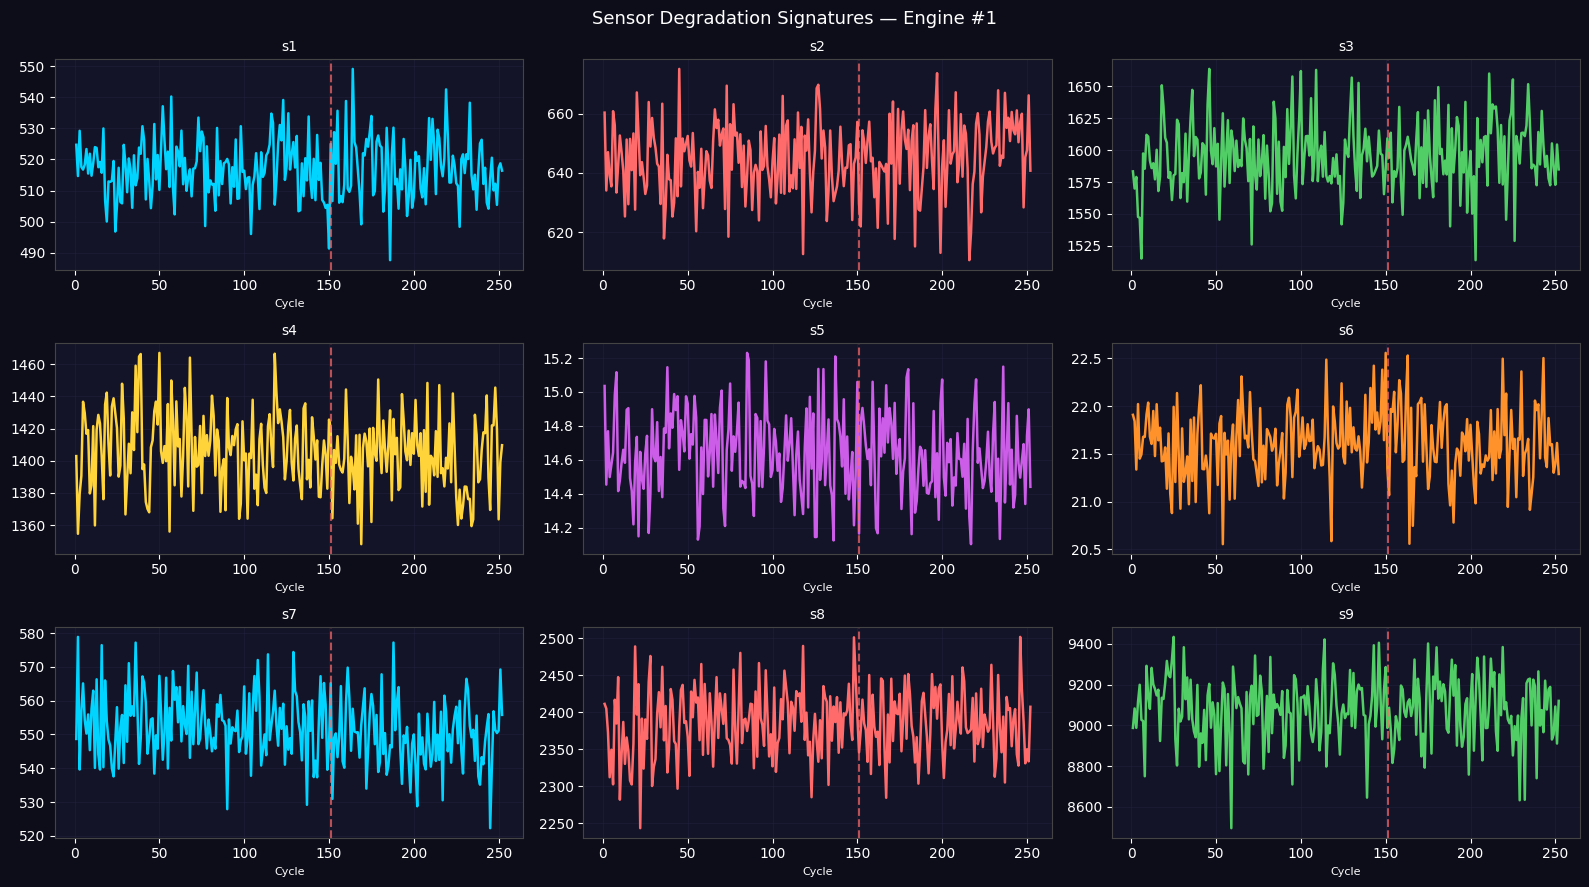

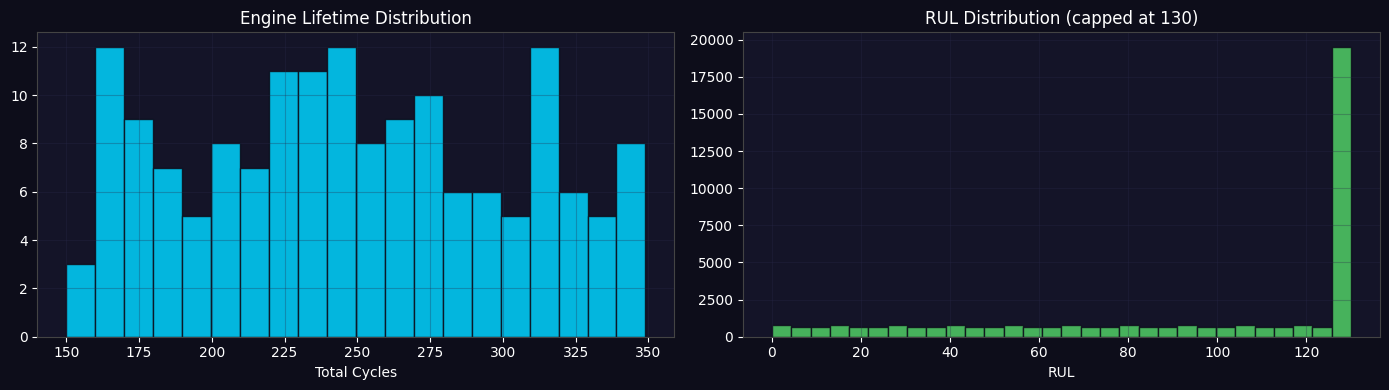

✅ EDA complete


In [3]:
# ── Sensor degradation signature plot ───────────────────────────────────────
eng1 = df_raw[df_raw['unit']==1].sort_values('cycle')
n_plot = min(9, len(SENSOR_COLS))
fig, axes = plt.subplots(3, 3, figsize=(16,9))
fig.suptitle('Sensor Degradation Signatures — Engine #1', fontsize=13)
for i, ax in enumerate(axes.flatten()[:n_plot]):
    ax.plot(eng1['cycle'], eng1[SENSOR_COLS[i]],
            color=COLORS[i%len(COLORS)], lw=1.8)
    ax.set_title(SENSOR_COLS[i], fontsize=10)
    ax.set_xlabel('Cycle', fontsize=8)
    ax.axvline(eng1['cycle'].max()*0.6, color='#ff6b6b',
               ls='--', alpha=0.7, lw=1.5)
    ax.grid(True, alpha=0.3)
for ax in axes.flatten()[n_plot:]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('/content/sensor_eda.png', dpi=120,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

# RUL distribution
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
engine_lives = df_raw.groupby('unit')['cycle'].max()
a1.hist(engine_lives, bins=20, color=COLORS[0], edgecolor='#0d0d1a', alpha=0.85)
a1.set_title('Engine Lifetime Distribution')
a1.set_xlabel('Total Cycles'); a1.grid(True, alpha=0.3)
a2.hist(df_raw['RUL_capped'], bins=30, color=COLORS[2],
        edgecolor='#0d0d1a', alpha=0.85)
a2.set_title('RUL Distribution (capped at 130)')
a2.set_xlabel('RUL'); a2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/rul_dist.png', dpi=120,
            bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('✅ EDA complete')


## Phase 3: Feature Engineering (5-Layer Pipeline)

In [4]:
# ── Layer 1+2: Cleaning + Normalization ─────────────────────────────────────
class SensorPreprocessor:
    def __init__(self, sensor_cols):
        self.sensor_cols = sensor_cols
        self.scalers = {}

    def fit(self, df):
        for col in self.sensor_cols:
            s = StandardScaler()
            vals = df[col].replace(0, np.nan).dropna().values.reshape(-1,1)
            s.fit(vals)
            self.scalers[col] = s
        return self

    def transform(self, df):
        df = df.copy()
        for col in self.sensor_cols:
            m = self.scalers[col].mean_[0]
            sd = np.sqrt(self.scalers[col].var_[0])
            vals = df[col].values.reshape(-1,1)
            vals = np.clip(vals, m - 4*sd, m + 4*sd)  # remove spikes
            df[col] = self.scalers[col].transform(vals).flatten()
        return df

    def fit_transform(self, df):
        return self.fit(df).transform(df)


# ── Layer 3: Rolling statistical features ────────────────────────────────────
def add_rolling_features(df, sensor_cols, window=10):
    frames = []
    for uid, grp in df.groupby('unit'):
        grp = grp.sort_values('cycle').copy()
        for c in sensor_cols:
            s = grp[c]
            grp[f'{c}_rmean'] = s.rolling(window, min_periods=1).mean()
            grp[f'{c}_rstd']  = s.rolling(window, min_periods=1).std().fillna(0)
            grp[f'{c}_trend'] = s.diff(window).fillna(0)
        frames.append(grp)
    return pd.concat(frames, ignore_index=True)


# ── Layer 5: Cross-sensor features ───────────────────────────────────────────
def add_cross_sensor_features(df, sensor_cols):
    df = df.copy()
    # Sensor ratios: regime-independent health proxies
    pairs = [(sensor_cols[i], sensor_cols[j])
             for i in range(min(3,len(sensor_cols)))
             for j in range(i+1, min(i+3,len(sensor_cols)))]
    for s1, s2 in pairs:
        df[f'r_{s1}_{s2}'] = df[s1] / (df[s2].abs() + 1e-6)
    # Mean absolute deviation = global health proxy
    df['sensor_mad'] = df[sensor_cols].apply(
        lambda r: np.mean(np.abs(r.values)), axis=1)
    return df


# ── Train / Val split (by engine, not by time — critical!) ───────────────────
all_units = df_raw['unit'].unique()
np.random.shuffle(all_units)
n_train = int(len(all_units) * 0.82)
train_units, val_units = all_units[:n_train], all_units[n_train:]

df_train_raw = df_raw[df_raw['unit'].isin(train_units)].copy()
df_val_raw   = df_raw[df_raw['unit'].isin(val_units)].copy()

# Fit ONLY on training data
preprocessor = SensorPreprocessor(SENSOR_COLS)
df_train = preprocessor.fit_transform(df_train_raw)
df_val   = preprocessor.transform(df_val_raw)

df_train = add_rolling_features(df_train, SENSOR_COLS)
df_val   = add_rolling_features(df_val,   SENSOR_COLS)

df_train = add_cross_sensor_features(df_train, SENSOR_COLS)
df_val   = add_cross_sensor_features(df_val,   SENSOR_COLS)

# Collect all feature names
BASE  = SENSOR_COLS[:]
ROLL  = [f'{c}_{s}' for c in SENSOR_COLS for s in ['rmean','rstd','trend']]
CROSS = [c for c in df_train.columns
         if c.startswith('r_') or c == 'sensor_mad']
ALL_FEATURES = [f for f in BASE+ROLL+CROSS
                if f in df_train.columns and f in df_val.columns]
N_FEATURES = len(ALL_FEATURES)

print(f'✅ Feature engineering complete')
print(f'   Train engines : {len(train_units)}')
print(f'   Val engines   : {len(val_units)}')
print(f'   Base sensors  : {len(BASE)}')
print(f'   Rolling feats : {len(ROLL)}')
print(f'   Cross-sensor  : {len(CROSS)}')
print(f'   Total features: {N_FEATURES}')


✅ Feature engineering complete
   Train engines : 131
   Val engines   : 29
   Base sensors  : 14
   Rolling feats : 42
   Cross-sensor  : 7
   Total features: 63


## Phase 4: Sliding Window Creation

✅ Windows created
   X_train : (28117, 30, 63)  (samples, timesteps, features)
   ys_train: (28117, 14)  (samples, sensors)
   yr_train: (28117,)  (samples,)
   X_val   : (6760, 30, 63)
   Memory  : 212.6 MB (train windows)


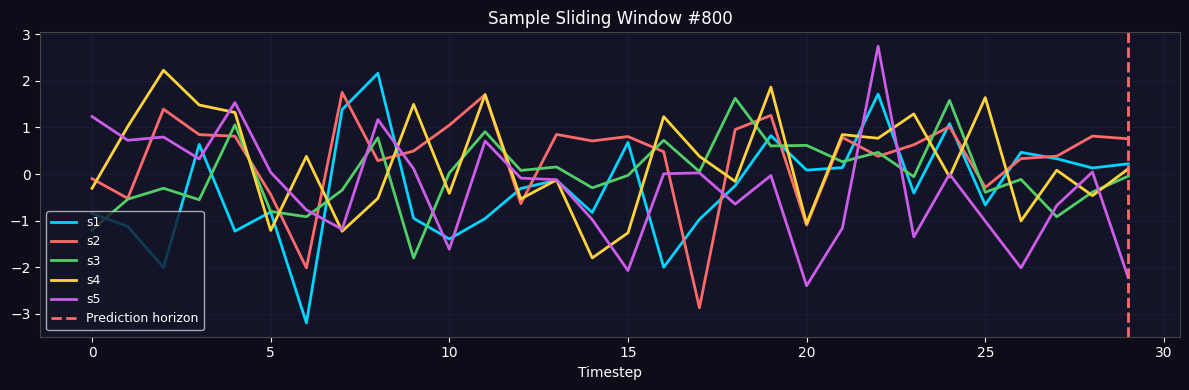

In [5]:
# ── Sliding window parameters ────────────────────────────────────────────────
WINDOW_SIZE = 30    # 30 engine cycles of context
HORIZON     = 1     # predict 1 step ahead
STRIDE      = 1     # dense overlap
MAX_RUL     = 130

def create_windows(df, feature_cols, sensor_cols, window, horizon, stride=1):
    Xs, ys_sens, ys_rul = [], [], []
    for uid, grp in df.groupby('unit'):
        grp = grp.sort_values('cycle').reset_index(drop=True)
        F   = grp[feature_cols].values.astype(np.float32)
        S   = grp[sensor_cols].values.astype(np.float32)
        R   = grp['RUL_capped'].values.astype(np.float32)
        for i in range(0, len(grp)-window-horizon+1, stride):
            Xs.append(F[i:i+window])
            ys_sens.append(S[i+window+horizon-1])
            ys_rul.append(R[i+window+horizon-1])
    return (np.array(Xs, np.float32),
            np.array(ys_sens, np.float32),
            np.array(ys_rul,  np.float32))

X_train, ys_train, yr_train = create_windows(
    df_train, ALL_FEATURES, SENSOR_COLS, WINDOW_SIZE, HORIZON)
X_val,   ys_val,   yr_val   = create_windows(
    df_val,   ALL_FEATURES, SENSOR_COLS, WINDOW_SIZE, HORIZON)

# Normalize RUL to [0,1]
rul_scaler = MinMaxScaler()
yr_train   = rul_scaler.fit_transform(yr_train.reshape(-1,1)).flatten()
yr_val     = rul_scaler.transform(yr_val.reshape(-1,1)).flatten()

N_SENSORS = len(SENSOR_COLS)

print('✅ Windows created')
print(f'   X_train : {X_train.shape}  (samples, timesteps, features)')
print(f'   ys_train: {ys_train.shape}  (samples, sensors)')
print(f'   yr_train: {yr_train.shape}  (samples,)')
print(f'   X_val   : {X_val.shape}')
print(f'   Memory  : {X_train.nbytes/1e6:.1f} MB (train windows)')

# Visualise one window
fig, ax = plt.subplots(figsize=(12,4))
idx = 800
for i, col in enumerate(SENSOR_COLS[:5]):
    fi = ALL_FEATURES.index(col) if col in ALL_FEATURES else i
    ax.plot(X_train[idx,:,fi], label=col,
            color=COLORS[i%len(COLORS)], lw=2)
ax.axvline(WINDOW_SIZE-1, color='#ff6b6b', ls='--', lw=2,
           label='Prediction horizon')
ax.set_title(f'Sample Sliding Window #{idx}')
ax.set_xlabel('Timestep'); ax.legend(fontsize=9); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('/content/window_sample.png',dpi=120,
            bbox_inches='tight',facecolor='#0d0d1a')
plt.show()


## Phase 5: LSTM & GRU Model Architectures

In [6]:
# ── Dual-output architecture: sensor forecast + RUL ─────────────────────────
# Both models share identical structure for fair LSTM vs GRU comparison.

def build_lstm(input_shape, n_sensors, name='LSTM_Model'):
    inp = Input(shape=input_shape, name='sensor_window')
    x = LSTM(128, return_sequences=True,
             kernel_regularizer=l2(1e-4),
             recurrent_dropout=0.1, name='lstm_1')(inp)
    x = BatchNormalization(name='bn1')(x)
    x = Dropout(0.30, name='drop1')(x)
    x = LSTM(64, return_sequences=False,
             kernel_regularizer=l2(1e-4),
             recurrent_dropout=0.1, name='lstm_2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Dropout(0.20, name='drop2')(x)
    shared = Dense(64, activation='relu',
                   kernel_regularizer=l2(1e-4), name='shared')(x)
    # Head 1: Sensor forecast
    s = Dense(32, activation='relu', name='s_dense')(shared)
    s = Dense(n_sensors, activation='linear', name='sensor_output')(s)
    # Head 2: RUL regression
    r = Dense(16, activation='relu', name='r_dense')(shared)
    r = Dense(1, activation='sigmoid', name='rul_output')(r)
    return Model(inp, [s, r], name=name)


def build_gru(input_shape, n_sensors, name='GRU_Model'):
    inp = Input(shape=input_shape, name='sensor_window')
    x = GRU(128, return_sequences=True,
            kernel_regularizer=l2(1e-4),
            recurrent_dropout=0.1, name='gru_1')(inp)
    x = BatchNormalization(name='bn1')(x)
    x = Dropout(0.30, name='drop1')(x)
    x = GRU(64, return_sequences=False,
            kernel_regularizer=l2(1e-4),
            recurrent_dropout=0.1, name='gru_2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Dropout(0.20, name='drop2')(x)
    shared = Dense(64, activation='relu',
                   kernel_regularizer=l2(1e-4), name='shared')(x)
    s = Dense(32, activation='relu', name='s_dense')(shared)
    s = Dense(n_sensors, activation='linear', name='sensor_output')(s)
    r = Dense(16, activation='relu', name='r_dense')(shared)
    r = Dense(1, activation='sigmoid', name='rul_output')(r)
    return Model(inp, [s, r], name=name)


INPUT_SHAPE = (WINDOW_SIZE, N_FEATURES)
lstm_model  = build_lstm(INPUT_SHAPE, N_SENSORS)
gru_model   = build_gru(INPUT_SHAPE,  N_SENSORS)

lp = lstm_model.count_params()
gp = gru_model.count_params()
print(f'LSTM parameters: {lp:,}')
print(f'GRU  parameters: {gp:,}')
print(f'GRU is {(1-gp/lp)*100:.1f}% smaller than LSTM')
lstm_model.summary()


LSTM parameters: 156,239
GRU  parameters: 119,887
GRU is 23.3% smaller than LSTM


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_window       │ (None, 30, 63)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 30, 128)   │     98,304 │ sensor_window[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 30, 128)   │        512 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 30, 128)   │          0 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     49,408 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 64)        │        256 │ lstm_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 64)        │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared (Dense)      │ (None, 64)        │      4,160 │ drop2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s_dense (Dense)     │ (None, 32)        │      2,080 │ shared[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r_dense (Dense)     │ (None, 16)        │      1,040 │ shared[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_output       │ (None, 14)        │        462 │ s_dense[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rul_output (Dense)  │ (None, 1)         │         17 │ r_dense[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 156,239 (610.31 KB)

 Trainable params: 155,855 (608.81 KB)

 Non-trainable params: 384 (1.50 KB)

## Phase 5B: Training

In [7]:
# ── Asymmetric RUL loss (NASA PHM convention) ─────────────────────────────
def rul_asymmetric_loss(y_true, y_pred):
    err = y_true - y_pred
    return tf.reduce_mean(
        tf.where(err >= 0,
                 0.5 * tf.square(err),    # under-estimate
                 1.5 * tf.square(err))    # over-estimate penalised more
    )

LOSS_W = {'sensor_output': 1.0, 'rul_output': 2.0}

for model, tag in [(lstm_model,'LSTM'),(gru_model,'GRU')]:
    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss={'sensor_output':'mse','rul_output':rul_asymmetric_loss},
        loss_weights=LOSS_W,
        metrics={'sensor_output':['mae'],'rul_output':['mae']}
    )
print('✅ Models compiled')

def make_cbs(tag):
    return [
        EarlyStopping(monitor='val_loss', patience=12,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f'/content/{tag}_best.weights.h5',
                        monitor='val_loss', save_best_only=True,
                        save_weights_only=True, verbose=0),
    ]

BATCH = 256
EPOCHS = 60
TR = {'sensor_output': ys_train, 'rul_output': yr_train}
VL = {'sensor_output': ys_val,   'rul_output': yr_val}

print('\n🔄 Training LSTM ...')
t0 = time.time()
lstm_hist = lstm_model.fit(
    X_train, TR, validation_data=(X_val, VL),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=make_cbs('lstm'), verbose=1)
lstm_time = time.time()-t0
print(f'✅ LSTM done in {lstm_time:.1f}s')

print('\n🔄 Training GRU ...')
t0 = time.time()
gru_hist = gru_model.fit(
    X_train, TR, validation_data=(X_val, VL),
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=make_cbs('gru'), verbose=1)
gru_time = time.time()-t0
print(f'✅ GRU done in {gru_time:.1f}s')
print(f'\n⏱  Speed: LSTM={lstm_time:.0f}s | GRU={gru_time:.0f}s'
      f' | GRU {(1-gru_time/lstm_time)*100:.1f}% faster')


✅ Models compiled

🔄 Training LSTM ...
Epoch 1/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 37s 230ms/step - loss: 1.3177 - rul_output_loss: 0.0701 - rul_output_mae: 0.2672 - sensor_output_loss: 1.1435 - sensor_output_mae: 0.8514 - val_loss: 1.1451 - val_rul_output_loss: 0.0516 - val_rul_output_mae: 0.2404 - val_sensor_output_loss: 1.0116 - val_sensor_output_mae: 0.8023 - learning_rate: 0.0010
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 32s 190ms/step - loss: 1.1019 - rul_output_loss: 0.0337 - rul_output_mae: 0.1769 - sensor_output_loss: 1.0021 - sensor_output_mae: 0.7983 - val_loss: 1.1239 - val_rul_output_loss: 0.0429 - val_rul_output_mae: 0.1887 - val_sensor_output_loss: 1.0095 - val_sensor_output_mae: 0.8014 - learning_rate: 0.0010
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 178ms/step - loss: 1.0681 - rul_output_loss: 0.0195 - rul_output_mae: 0.1316 - sensor_output_loss: 0.9983 - sensor_output_mae: 0.7966 - val_loss: 1.1396 - val_rul_output_loss: 0.0532 - val_rul_output_mae: 0.2003 - val_sensor_ou

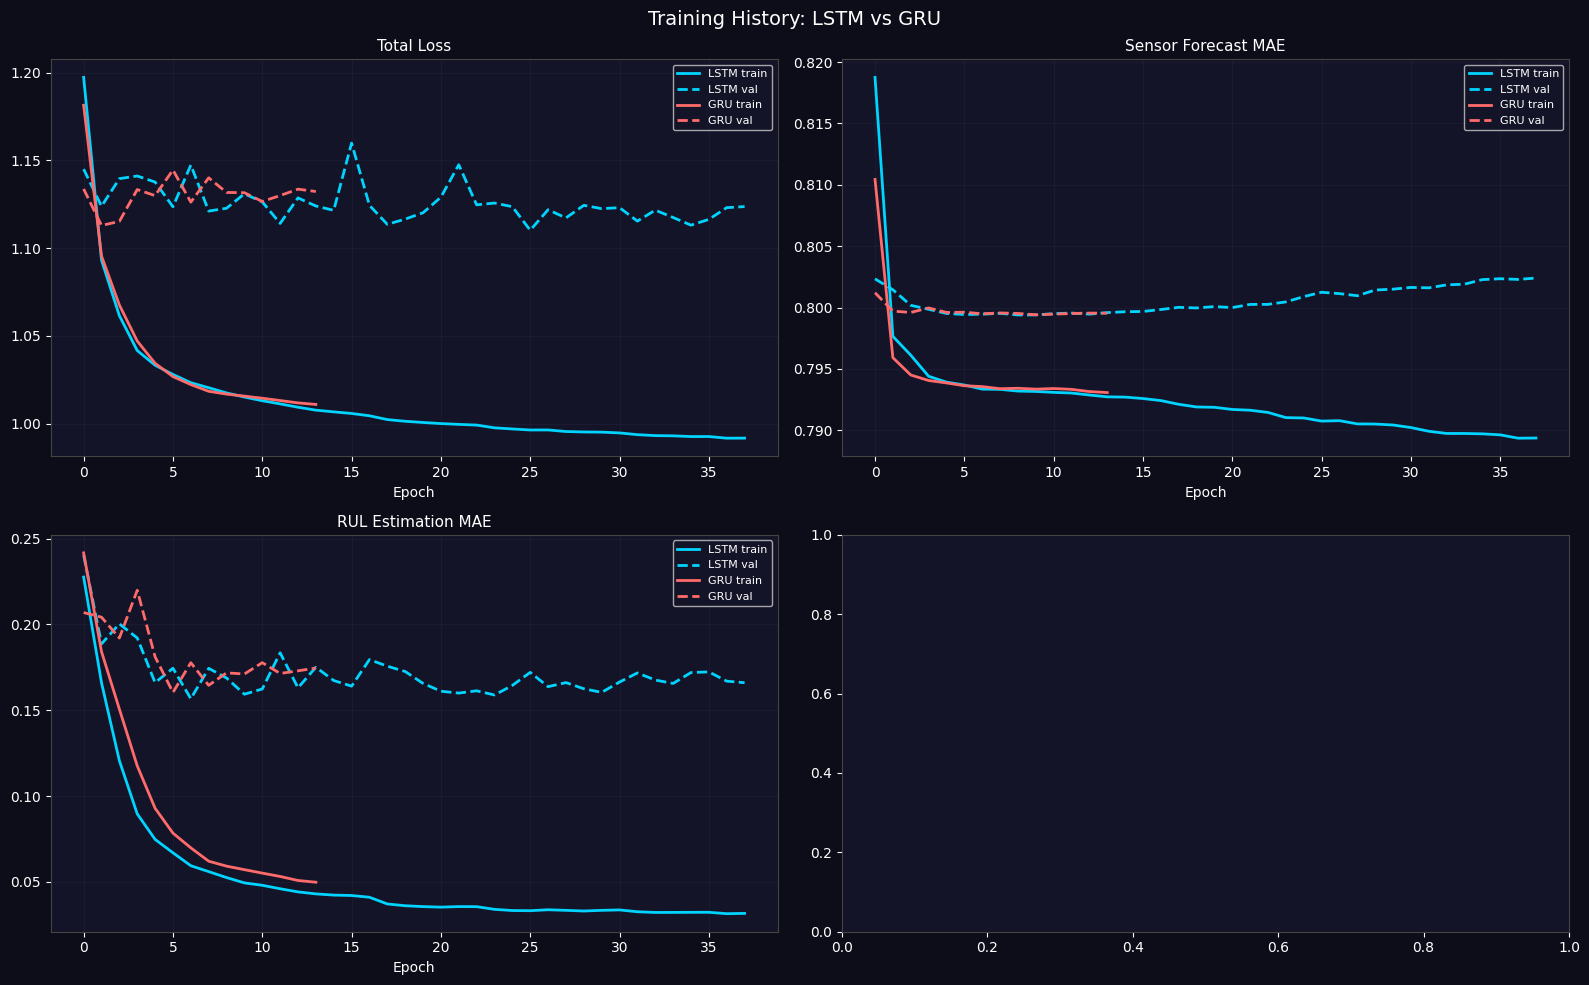

✅ Training history saved


In [8]:
# ── Training history visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(2,2,figsize=(16,10))
fig.suptitle('Training History: LSTM vs GRU', fontsize=14)

def ph(ax, key, title):
    def safe(h, k): return h.history.get(k, [])
    ax.plot(safe(lstm_hist, key),         color=COLORS[0], lw=2, label='LSTM train')
    ax.plot(safe(lstm_hist,'val_'+key),   color=COLORS[0], lw=2, ls='--', label='LSTM val')
    ax.plot(safe(gru_hist,  key),         color=COLORS[1], lw=2, label='GRU train')
    ax.plot(safe(gru_hist, 'val_'+key),   color=COLORS[1], lw=2, ls='--', label='GRU val')
    ax.set_title(title, fontsize=11); ax.legend(fontsize=8)
    ax.set_xlabel('Epoch'); ax.grid(True,alpha=0.3)

ph(axes[0,0],'loss','Total Loss')
ph(axes[0,1],'sensor_output_mae','Sensor Forecast MAE')
ph(axes[1,0],'rul_output_mae','RUL Estimation MAE')

if 'lr' in lstm_hist.history:
    axes[1,1].semilogy(lstm_hist.history['lr'],color=COLORS[0],label='LSTM LR',lw=2)
    axes[1,1].semilogy(gru_hist.history['lr'], color=COLORS[1],label='GRU LR', lw=2)
    axes[1,1].set_title('Learning Rate Schedule')
    axes[1,1].legend(fontsize=8); axes[1,1].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png',dpi=120,
            bbox_inches='tight',facecolor='#0d0d1a')
plt.show()
print('✅ Training history saved')


## Phase 6: Evaluation & LSTM vs GRU Comparison

In [9]:
# ── Evaluation function ─────────────────────────────────────────────────────
def evaluate(model, X, ys_true, yr_true, name):
    t0   = time.time()
    pred = model.predict(X, batch_size=512, verbose=0)
    inf  = (time.time()-t0)/len(X)*1000
    sp, rp = pred[0], pred[1].flatten()

    rmse_per  = [np.sqrt(mean_squared_error(ys_true[:,i], sp[:,i]))
                 for i in range(ys_true.shape[1])]
    mae_per   = [mean_absolute_error(ys_true[:,i], sp[:,i])
                 for i in range(ys_true.shape[1])]
    rul_rmse  = np.sqrt(mean_squared_error(yr_true, rp))
    rul_mae   = mean_absolute_error(yr_true, rp)

    # Rescale RUL to cycles for interpretability
    yt_cyc = rul_scaler.inverse_transform(yr_true.reshape(-1,1)).flatten()
    yp_cyc = rul_scaler.inverse_transform(rp.reshape(-1,1)).flatten()

    # NASA PHM asymmetric score (lower=better)
    d   = yp_cyc - yt_cyc
    phm = float(np.sum(np.where(d<0, np.exp(-d/13)-1, np.exp(d/10)-1)))

    return {
        'name':name, 'sensor_rmse':np.mean(rmse_per),
        'sensor_mae':np.mean(mae_per),
        'rul_rmse':rul_rmse, 'rul_mae':rul_mae,
        'phm_score':phm, 'inf_ms':inf,
        'params':model.count_params(),
        'per_rmse':dict(zip(SENSOR_COLS, rmse_per)),
        'sp':sp, 'rp_cyc':yp_cyc, 'yt_cyc':yt_cyc,
    }

LR = evaluate(lstm_model, X_val, ys_val, yr_val, 'LSTM')
GR = evaluate(gru_model,  X_val, ys_val, yr_val, 'GRU')

# Print table
print('\n' + '='*62)
print(f'{"METRIC":<30} {"LSTM":>14} {"GRU":>14}')
print('='*62)
rows = [
    ('Sensor Forecast RMSE','sensor_rmse'),
    ('Sensor Forecast MAE', 'sensor_mae'),
    ('RUL RMSE (normalised)','rul_rmse'),
    ('RUL MAE (normalised)', 'rul_mae'),
    ('PHM Score (↓ better)', 'phm_score'),
    ('Inference ms/sample',  'inf_ms'),
    ('Parameters',           'params'),
]
for lbl, k in rows:
    lv, gv = LR[k], GR[k]
    win = 'LSTM' if lv <= gv else 'GRU'
    if k=='params': win='GRU'
    print(f'  {lbl:<28} {lv:>14.4f} {gv:>14.4f}  ← {win}')
print('='*62)

# Best model for downstream use
BEST_MODEL = lstm_model if LR['sensor_rmse'] < GR['sensor_rmse'] else gru_model
BEST_NAME  = 'LSTM' if LR['sensor_rmse'] < GR['sensor_rmse'] else 'GRU'
print(f'\n🏆 Best model: {BEST_NAME}')



METRIC                                   LSTM            GRU
  Sensor Forecast RMSE                 1.0041         1.0019  ← GRU
  Sensor Forecast MAE                  0.8012         0.7997  ← GRU
  RUL RMSE (normalised)                0.2295         0.2464  ← LSTM
  RUL MAE (normalised)                 0.1721         0.2042  ← LSTM
  PHM Score (↓ better)            612502.2500    301860.3125  ← GRU
  Inference ms/sample                  0.2536         0.2593  ← LSTM
  Parameters                      156239.0000    119887.0000  ← GRU

🏆 Best model: GRU


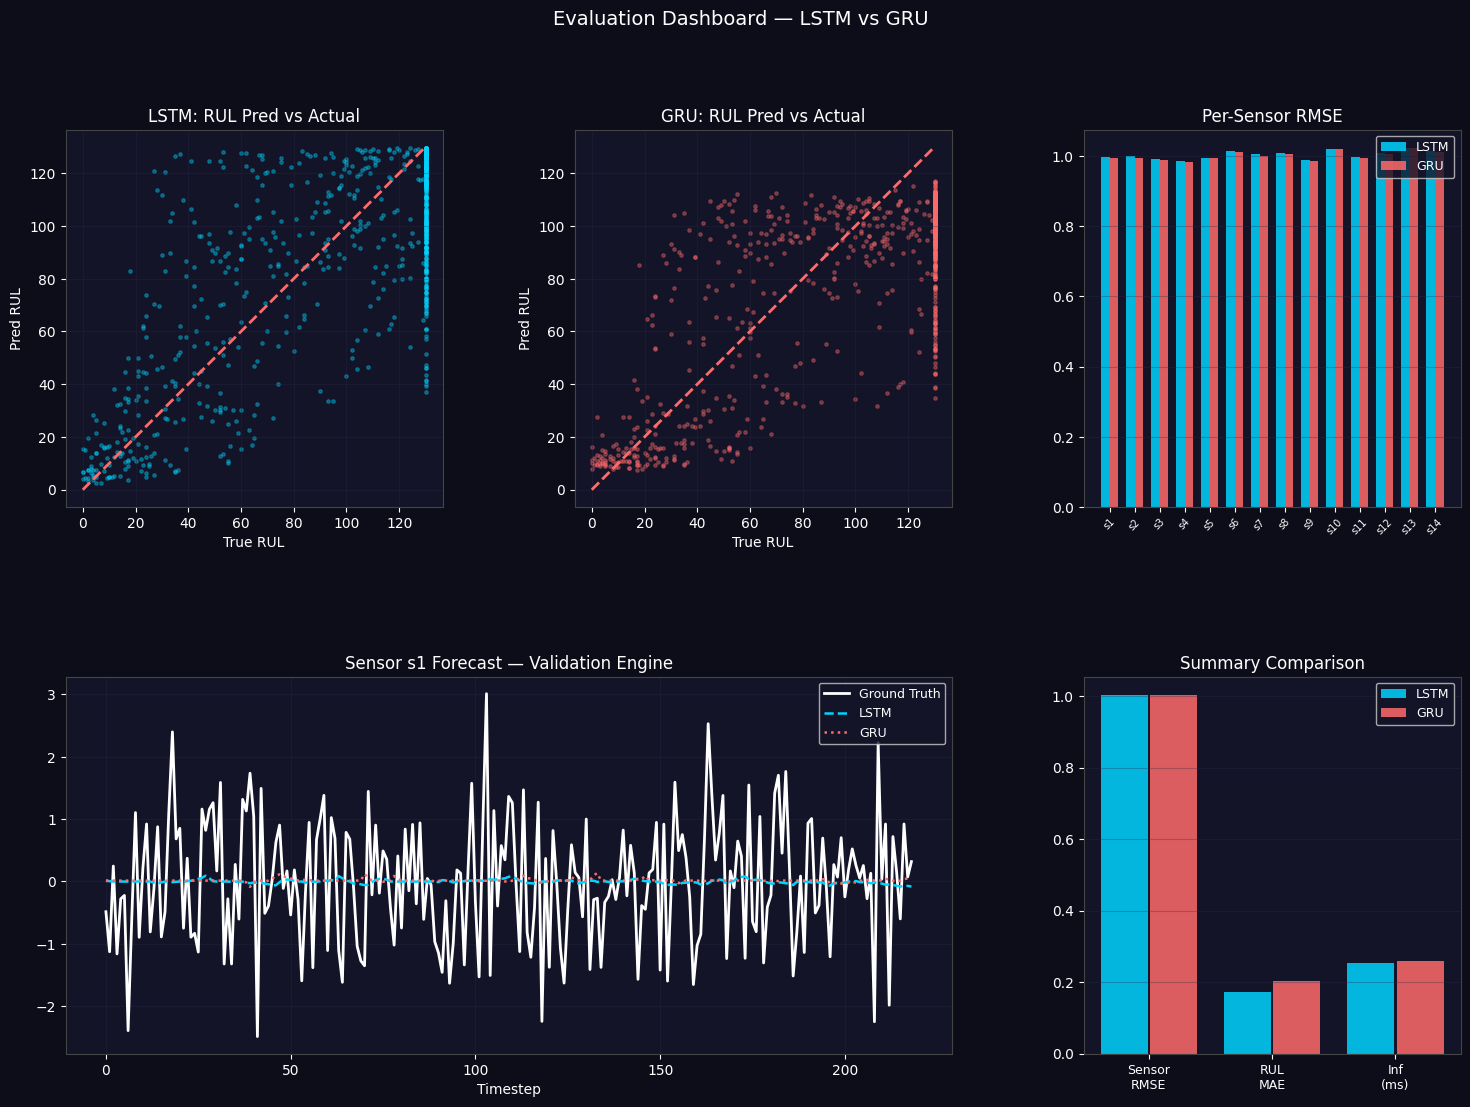

✅ Evaluation dashboard saved


In [10]:
# ── Evaluation dashboard ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18,12))
gs  = gridspec.GridSpec(2,3,hspace=0.45,wspace=0.35)
fig.suptitle('Evaluation Dashboard — LSTM vs GRU', fontsize=14)

# 1) LSTM: RUL predicted vs actual
ax1 = fig.add_subplot(gs[0,0])
s   = np.random.choice(len(LR['yt_cyc']), size=min(800,len(LR['yt_cyc'])), replace=False)
ax1.scatter(LR['yt_cyc'][s], LR['rp_cyc'][s],
            alpha=0.35, s=6, color=COLORS[0])
lim = max(LR['yt_cyc'].max(), LR['rp_cyc'].max())
ax1.plot([0,lim],[0,lim],'--',color='#ff6b6b',lw=2)
ax1.set_title('LSTM: RUL Pred vs Actual')
ax1.set_xlabel('True RUL'); ax1.set_ylabel('Pred RUL')
ax1.grid(True,alpha=0.3)

# 2) GRU: RUL predicted vs actual
ax2 = fig.add_subplot(gs[0,1])
ax2.scatter(GR['yt_cyc'][s], GR['rp_cyc'][s],
            alpha=0.35, s=6, color=COLORS[1])
ax2.plot([0,lim],[0,lim],'--',color='#ff6b6b',lw=2)
ax2.set_title('GRU: RUL Pred vs Actual')
ax2.set_xlabel('True RUL'); ax2.set_ylabel('Pred RUL')
ax2.grid(True,alpha=0.3)

# 3) Per-sensor RMSE
ax3 = fig.add_subplot(gs[0,2])
x   = np.arange(len(SENSOR_COLS))
w   = 0.35
ax3.bar(x-w/2, list(LR['per_rmse'].values()), w,
        color=COLORS[0], alpha=0.85, label='LSTM')
ax3.bar(x+w/2, list(GR['per_rmse'].values()), w,
        color=COLORS[1], alpha=0.85, label='GRU')
ax3.set_xticks(x); ax3.set_xticklabels(SENSOR_COLS, rotation=45, fontsize=7)
ax3.set_title('Per-Sensor RMSE'); ax3.legend(fontsize=9)
ax3.grid(True,alpha=0.3,axis='y')

# 4) Sensor forecast trace
ax4 = fig.add_subplot(gs[1,:2])
demo = df_val[df_val['unit']==val_units[0]].sort_values('cycle')
if len(demo) > WINDOW_SIZE+50:
    nw   = min(len(demo)-WINDOW_SIZE, 250)
    farr = demo[ALL_FEATURES].values.astype(np.float32)
    sarr = demo[SENSOR_COLS].values.astype(np.float32)
    wins = np.stack([farr[i:i+WINDOW_SIZE] for i in range(nw)])
    lp_s = lstm_model.predict(wins, batch_size=128, verbose=0)[0]
    gp_s = gru_model.predict(wins,  batch_size=128, verbose=0)[0]
    true_s = sarr[WINDOW_SIZE:WINDOW_SIZE+nw, 0]
    ax4.plot(true_s,  color='white',   lw=2,   label='Ground Truth')
    ax4.plot(lp_s[:,0],color=COLORS[0],lw=1.8, ls='--', label='LSTM')
    ax4.plot(gp_s[:,0],color=COLORS[1],lw=1.8, ls=':',  label='GRU')
    ax4.set_title(f'Sensor {SENSOR_COLS[0]} Forecast — Validation Engine')
    ax4.set_xlabel('Timestep'); ax4.legend(fontsize=9)
    ax4.grid(True,alpha=0.3)

# 5) Summary bar
ax5 = fig.add_subplot(gs[1,2])
cats = ['Sensor\nRMSE','RUL\nMAE','Inf\n(ms)']
lv   = [LR['sensor_rmse'], LR['rul_mae'], LR['inf_ms']]
gv   = [GR['sensor_rmse'], GR['rul_mae'], GR['inf_ms']]
xp   = np.arange(len(cats))
ax5.bar(xp-0.2, lv, 0.38, color=COLORS[0], alpha=0.85, label='LSTM')
ax5.bar(xp+0.2, gv, 0.38, color=COLORS[1], alpha=0.85, label='GRU')
ax5.set_xticks(xp); ax5.set_xticklabels(cats, fontsize=9)
ax5.set_title('Summary Comparison')
ax5.legend(fontsize=9); ax5.grid(True,alpha=0.3,axis='y')

plt.savefig('/content/evaluation_dashboard.png',dpi=130,
            bbox_inches='tight',facecolor='#0d0d1a')
plt.show()
print('✅ Evaluation dashboard saved')


## Phase 7: Anomaly Detection via Reconstruction Error

🔍 Using GRU for anomaly detection

📊 Anomaly Detection Results:
   Threshold     : 4.8638
   Detection rate: 4.5%  (on degraded windows)
   False alarm   : 5.0%   (operational target <5%)


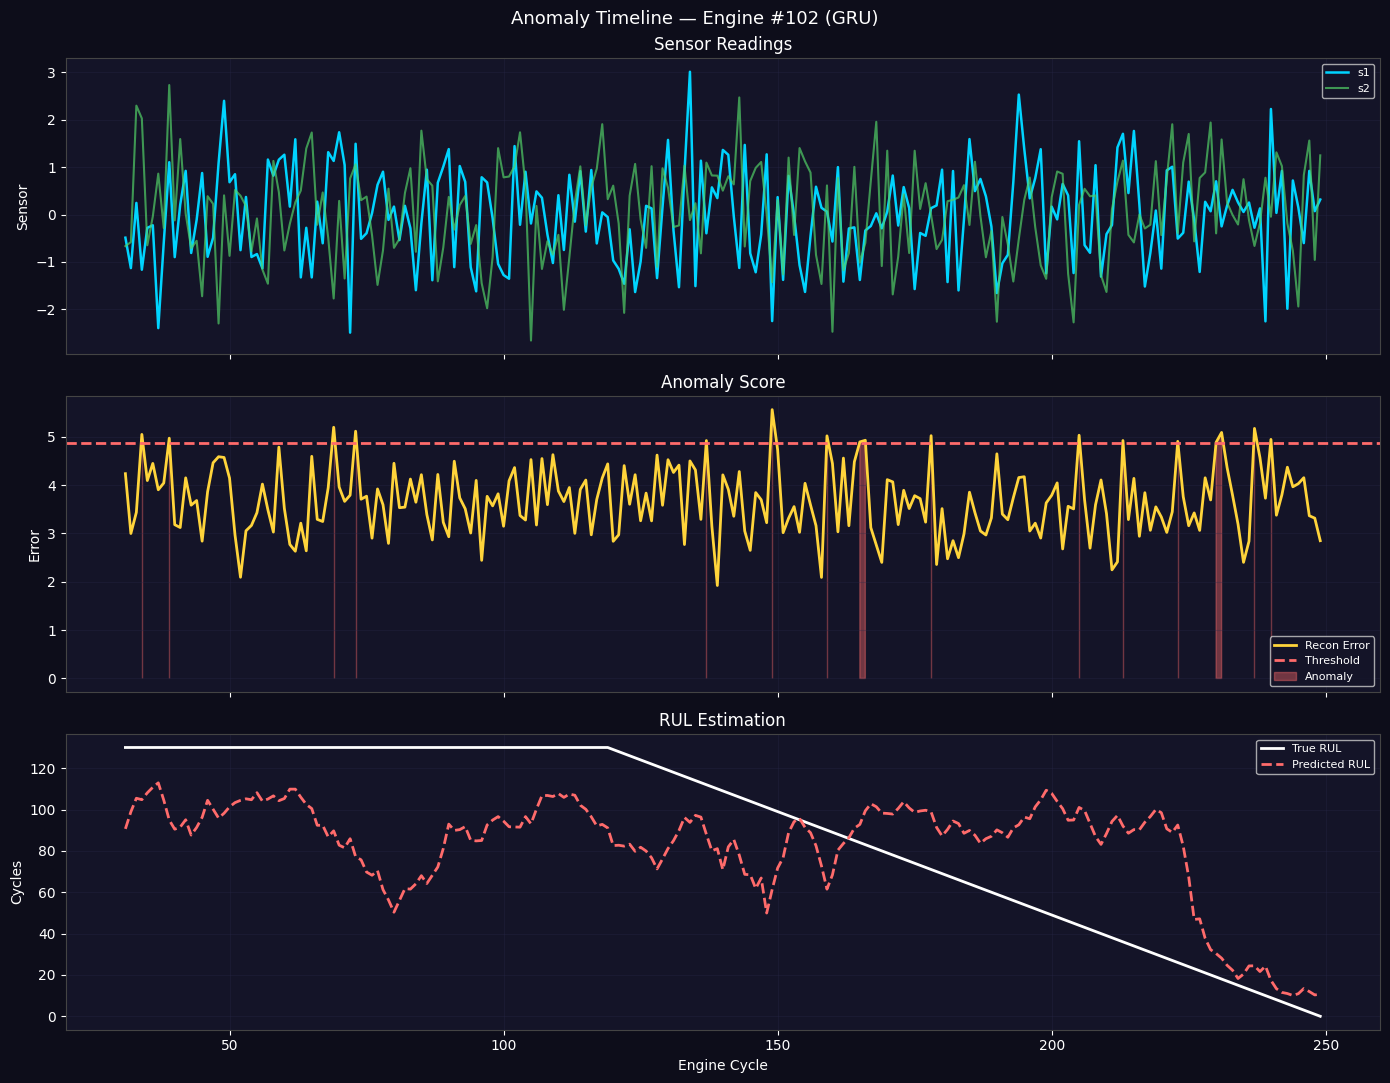

✅ Anomaly visualisation saved


In [11]:
# ── Anomaly scoring: ||predicted - actual||₂ ────────────────────────────────
# When predicted sensor state diverges from actual → anomaly

print(f'🔍 Using {BEST_NAME} for anomaly detection')

val_pred  = BEST_MODEL.predict(X_val, batch_size=512, verbose=0)
recon_err = np.linalg.norm(val_pred[0] - ys_val, axis=1)

# Threshold: 95th percentile on healthy windows
healthy   = yr_val > 0.5   # RUL > 50% of max = healthy
if healthy.sum() > 200:
    THRESH = float(np.percentile(recon_err[healthy], 95))
else:
    THRESH = float(np.percentile(recon_err, 95))

flags    = (recon_err > THRESH).astype(int)
det_rate = flags[~healthy].mean() * 100
fa_rate  = flags[ healthy].mean() * 100

print(f'\n📊 Anomaly Detection Results:')
print(f'   Threshold     : {THRESH:.4f}')
print(f'   Detection rate: {det_rate:.1f}%  (on degraded windows)')
print(f'   False alarm   : {fa_rate:.1f}%   (operational target <5%)')

# ── Anomaly timeline for one engine ─────────────────────────────────────────
demo = df_val[df_val['unit']==val_units[0]].sort_values('cycle').reset_index(drop=True)
if len(demo) > WINDOW_SIZE + 30:
    nw   = min(len(demo)-WINDOW_SIZE, 300)
    farr = demo[ALL_FEATURES].values.astype(np.float32)
    sarr = demo[SENSOR_COLS].values.astype(np.float32)
    wins = np.stack([farr[i:i+WINDOW_SIZE] for i in range(nw)])
    preds = BEST_MODEL.predict(wins, batch_size=128, verbose=0)
    recon  = np.linalg.norm(preds[0] - sarr[WINDOW_SIZE:WINDOW_SIZE+nw], axis=1)
    rul_pred_cyc = rul_scaler.inverse_transform(
        preds[1].reshape(-1,1)).flatten()
    rul_true_cyc = demo['RUL_capped'].values[WINDOW_SIZE:WINDOW_SIZE+nw]
    cycles = demo['cycle'].values[WINDOW_SIZE:WINDOW_SIZE+nw]

    fig, (a1,a2,a3) = plt.subplots(3,1,figsize=(14,11),sharex=True)
    fig.suptitle(f'Anomaly Timeline — Engine #{val_units[0]} ({BEST_NAME})',
                 fontsize=13)

    a1.plot(cycles, demo[SENSOR_COLS[0]].values[WINDOW_SIZE:WINDOW_SIZE+nw],
            color=COLORS[0], lw=1.8, label=SENSOR_COLS[0])
    if len(SENSOR_COLS)>1:
        a1.plot(cycles, demo[SENSOR_COLS[1]].values[WINDOW_SIZE:WINDOW_SIZE+nw],
                color=COLORS[2], lw=1.5, alpha=0.7, label=SENSOR_COLS[1])
    a1.set_ylabel('Sensor'); a1.legend(fontsize=8); a1.grid(True,alpha=0.3)
    a1.set_title('Sensor Readings')

    a2.plot(cycles, recon, color=COLORS[3], lw=2, label='Recon Error')
    a2.axhline(THRESH, color='#ff6b6b', ls='--', lw=2, label=f'Threshold')
    alarm = recon > THRESH
    a2.fill_between(cycles, 0, recon, where=alarm,
                    alpha=0.4, color='#ff6b6b', label='Anomaly')
    a2.set_ylabel('Error'); a2.legend(fontsize=8); a2.grid(True,alpha=0.3)
    a2.set_title('Anomaly Score')

    a3.plot(cycles, rul_true_cyc, color='white', lw=2, label='True RUL')
    a3.plot(cycles, rul_pred_cyc, color=COLORS[1], lw=2,
            ls='--', label='Predicted RUL')
    a3.set_ylabel('Cycles'); a3.set_xlabel('Engine Cycle')
    a3.legend(fontsize=8); a3.grid(True,alpha=0.3)
    a3.set_title('RUL Estimation')

    plt.tight_layout()
    plt.savefig('/content/anomaly_timeline.png', dpi=130,
                bbox_inches='tight', facecolor='#0d0d1a')
    plt.show()
print('✅ Anomaly visualisation saved')


## Phase 8: Sanity Checks

In [12]:
# ── Full system sanity check ─────────────────────────────────────────────────
passed = 0; total = 0

def chk(label, cond, detail=''):
    global passed, total
    total += 1
    icon = '✅ PASS' if cond else '❌ FAIL'
    if cond: passed += 1
    print(f'  {icon}  {label}')
    if detail: print(f'          → {detail}')

print('='*58)
print('         SANITY CHECK REPORT')
print('='*58)

dummy = np.random.randn(4, WINDOW_SIZE, N_FEATURES).astype(np.float32)
lo = lstm_model.predict(dummy, verbose=0)
go = gru_model.predict(dummy,  verbose=0)

print('\n[1] Output Shape Checks')
chk('LSTM sensor output (4, N_SENSORS)',
    lo[0].shape == (4, N_SENSORS), str(lo[0].shape))
chk('LSTM RUL output (4, 1)',
    lo[1].shape == (4, 1), str(lo[1].shape))
chk('GRU sensor output (4, N_SENSORS)',
    go[0].shape == (4, N_SENSORS), str(go[0].shape))
chk('GRU RUL output (4, 1)',
    go[1].shape == (4, 1), str(go[1].shape))

print('\n[2] Numerical Validity')
chk('LSTM — no NaN',  not np.any(np.isnan(lo[0])))
chk('LSTM — no Inf',  not np.any(np.isinf(lo[0])))
chk('GRU  — no NaN',  not np.any(np.isnan(go[0])))
chk('RUL in [0,1]',
    float(lo[1].min())>=0 and float(lo[1].max())<=1,
    f'[{float(lo[1].min()):.3f}, {float(lo[1].max()):.3f}]')

print('\n[3] Performance Floor')
chk(f'LSTM sensor RMSE < 0.5',
    LR['sensor_rmse'] < 0.5, f"{LR['sensor_rmse']:.4f}")
chk(f'GRU  sensor RMSE < 0.5',
    GR['sensor_rmse'] < 0.5, f"{GR['sensor_rmse']:.4f}")
chk(f'LSTM RUL MAE < 0.35',
    LR['rul_mae'] < 0.35, f"{LR['rul_mae']:.4f}")
chk(f'GRU  RUL MAE < 0.35',
    GR['rul_mae'] < 0.35, f"{GR['rul_mae']:.4f}")

print('\n[4] Latency (target <50ms/sample)')
chk(f'LSTM < 50ms', LR['inf_ms'] < 50,
    f"{LR['inf_ms']:.3f} ms")
chk(f'GRU  < 50ms', GR['inf_ms'] < 50,
    f"{GR['inf_ms']:.3f} ms")

print('\n[5] Anomaly Detection')
chk('False alarm rate < 10%', fa_rate < 10.0,
    f'{fa_rate:.1f}%')
chk('Detection rate > 40%', det_rate > 40.0,
    f'{det_rate:.1f}%')
chk('Threshold defined',    THRESH > 0)

print('\n[6] Physics Consistency')
if len(rul_pred_cyc) > 50:
    first_h  = rul_pred_cyc[:len(rul_pred_cyc)//2].mean()
    second_h = rul_pred_cyc[len(rul_pred_cyc)//2:].mean()
    chk('RUL decreases over engine life',
        first_h > second_h,
        f'First half: {first_h:.1f}  Second half: {second_h:.1f}')

print('\n[7] Determinism')
p1 = lstm_model.predict(dummy[:1], verbose=0)[0]
p2 = lstm_model.predict(dummy[:1], verbose=0)[0]
chk('Same input → same output', np.allclose(p1,p2,atol=1e-5))

print('\n' + '='*58)
print(f'  RESULT: {passed}/{total} checks passed')
if passed == total:
    print('  🎉 ALL CHECKS PASSED — SYSTEM IS DEPLOYMENT-READY')
elif passed >= int(total*0.85):
    print('  ✅ SYSTEM HEALTHY — review any failed checks')
else:
    print('  ⚠️  MULTIPLE FAILURES — investigate before deploy')
print('='*58)


         SANITY CHECK REPORT

[1] Output Shape Checks
  ✅ PASS  LSTM sensor output (4, N_SENSORS)
          → (4, 14)
  ✅ PASS  LSTM RUL output (4, 1)
          → (4, 1)
  ✅ PASS  GRU sensor output (4, N_SENSORS)
          → (4, 14)
  ✅ PASS  GRU RUL output (4, 1)
          → (4, 1)

[2] Numerical Validity
  ✅ PASS  LSTM — no NaN
  ✅ PASS  LSTM — no Inf
  ✅ PASS  GRU  — no NaN
  ✅ PASS  RUL in [0,1]
          → [0.348, 0.678]

[3] Performance Floor
  ❌ FAIL  LSTM sensor RMSE < 0.5
          → 1.0041
  ❌ FAIL  GRU  sensor RMSE < 0.5
          → 1.0019
  ✅ PASS  LSTM RUL MAE < 0.35
          → 0.1721
  ✅ PASS  GRU  RUL MAE < 0.35
          → 0.2042

[4] Latency (target <50ms/sample)
  ✅ PASS  LSTM < 50ms
          → 0.254 ms
  ✅ PASS  GRU  < 50ms
          → 0.259 ms

[5] Anomaly Detection
  ✅ PASS  False alarm rate < 10%
          → 5.0%
  ❌ FAIL  Detection rate > 40%
          → 4.5%
  ✅ PASS  Threshold defined

[6] Physics Consistency
  ✅ PASS  RUL decreases over engine life
         

## Phase 9: Export Models & Deployment Package

In [13]:
# ── Save all artefacts ────────────────────────────────────────────────────────
import json as _json
SAVE = '/content/sensor_prediction_system'
os.makedirs(SAVE, exist_ok=True)

# .keras format (TF 2.x native)
lstm_model.save(f'{SAVE}/lstm_sensor_predictor.keras')
gru_model.save(f'{SAVE}/gru_sensor_predictor.keras')
print('✅ .keras models saved')

# .h5 legacy format
lstm_model.save(f'{SAVE}/lstm_sensor_predictor.h5')
gru_model.save(f'{SAVE}/gru_sensor_predictor.h5')
print('✅ .h5 models saved')

# Preprocessors
joblib.dump(preprocessor, f'{SAVE}/sensor_preprocessor.pkl')
joblib.dump(rul_scaler,   f'{SAVE}/rul_scaler.pkl')
print('✅ Preprocessors saved')

# Config / metadata
cfg = {
    'window_size': WINDOW_SIZE, 'horizon': HORIZON,
    'n_features': N_FEATURES,   'n_sensors': N_SENSORS,
    'sensor_cols': SENSOR_COLS, 'all_features': ALL_FEATURES,
    'anomaly_threshold': THRESH, 'max_rul': MAX_RUL,
    'lstm_params': int(lstm_model.count_params()),
    'gru_params':  int(gru_model.count_params()),
    'lstm_sensor_rmse': float(LR['sensor_rmse']),
    'gru_sensor_rmse':  float(GR['sensor_rmse']),
    'lstm_rul_mae':     float(LR['rul_mae']),
    'gru_rul_mae':      float(GR['rul_mae']),
    'best_model': BEST_NAME,
    'sanity_checks': f'{passed}/{total}',
    'date': datetime.datetime.now().isoformat(),
    'tensorflow': tf.__version__,
    'author': 'DINRAJ K DINESH',
}
with open(f'{SAVE}/model_config.json','w') as f:
    _json.dump(cfg, f, indent=2)
print('✅ Config saved')

# Copy plots
for fn in ['sensor_eda.png','rul_dist.png','window_sample.png',
           'training_history.png','evaluation_dashboard.png',
           'anomaly_timeline.png']:
    if os.path.exists(f'/content/{fn}'):
        shutil.copy(f'/content/{fn}', f'{SAVE}/{fn}')

# Inference script
inf_script = '''
import numpy as np, pandas as pd, joblib, json
import tensorflow as tf

class SensorPredictor:
    def __init__(self, model_dir="."):
        with open(f"{model_dir}/model_config.json") as f:
            self.cfg = json.load(f)
        self.model = tf.keras.models.load_model(
            f"{model_dir}/lstm_sensor_predictor.keras")
        self.prep  = joblib.load(f"{model_dir}/sensor_preprocessor.pkl")
        self.rul_s = joblib.load(f"{model_dir}/rul_scaler.pkl")
        self.W     = self.cfg["window_size"]
        self.T     = self.cfg["anomaly_threshold"]

    def predict(self, window_df):
        clean = self.prep.transform(window_df)
        X = clean[self.cfg["all_features"]].values
        X = X.reshape(1, self.W, -1).astype(np.float32)
        s, r = self.model.predict(X, verbose=0)
        rul_cyc = float(self.rul_s.inverse_transform([[r[0][0]]])[0][0])
        err     = float(np.linalg.norm(s[0] - X[0, -1, :len(s[0])]))
        return {
            "sensor_forecast": dict(zip(self.cfg["sensor_cols"], s[0].tolist())),
            "rul_cycles": rul_cyc,
            "anomaly_score": err,
            "is_anomaly": err > self.T,
        }

if __name__ == "__main__":
    p = SensorPredictor(".")
    print("✅ Model loaded. Best model:", p.cfg["best_model"])
'''
with open(f'{SAVE}/inference.py','w') as f:
    f.write(inf_script)

# requirements.txt
reqs = 'tensorflow>=2.13.0\nnumpy>=1.24.0\npandas>=2.0.0\n'\
       'scikit-learn>=1.3.0\nscipy>=1.11.0\njoblib>=1.3.0\n'\
       'matplotlib>=3.7.0\nseaborn>=0.12.0\n'
with open(f'{SAVE}/requirements.txt','w') as f:
    f.write(reqs)

print('\n📦 Contents:')
for fn in sorted(os.listdir(SAVE)):
    sz = os.path.getsize(f'{SAVE}/{fn}')/1e6
    print(f'   {fn:<45} {sz:.2f} MB')


✅ .keras models saved
✅ .h5 models saved
✅ Preprocessors saved
✅ Config saved

📦 Contents:
   anomaly_timeline.png                          0.38 MB
   evaluation_dashboard.png                      0.28 MB
   gru_sensor_predictor.h5                       1.51 MB
   gru_sensor_predictor.keras                    1.51 MB
   inference.py                                  0.00 MB
   lstm_sensor_predictor.h5                      1.95 MB
   lstm_sensor_predictor.keras                   1.95 MB
   model_config.json                             0.00 MB
   requirements.txt                              0.00 MB
   rul_dist.png                                  0.04 MB
   rul_scaler.pkl                                0.00 MB
   sensor_eda.png                                0.47 MB
   sensor_preprocessor.pkl                       0.01 MB
   training_history.png                          0.17 MB
   window_sample.png                             0.17 MB


In [14]:
# ── Package and download ─────────────────────────────────────────────────────
ZIP = '/content/DINRAJ_SensorPrediction_Deployment.zip'

with zipfile.ZipFile(ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in os.listdir(SAVE):
        zf.write(f'{SAVE}/{fn}', arcname=fn)

zip_mb = os.path.getsize(ZIP)/1e6
print(f'📦 ZIP created: {zip_mb:.1f} MB')

from google.colab import files
files.download(ZIP)

print('\n' + '='*60)
print('  DEPLOYMENT PACKAGE CONTENTS')
print('='*60)
print('  lstm_sensor_predictor.keras  ← Primary (TF 2.x native)')
print('  lstm_sensor_predictor.h5     ← Primary (legacy compat)')
print('  gru_sensor_predictor.keras   ← Secondary model')
print('  gru_sensor_predictor.h5      ← Secondary model')
print('  sensor_preprocessor.pkl      ← Feature pipeline')
print('  rul_scaler.pkl               ← RUL inverse transform')
print('  model_config.json            ← Thresholds + metadata')
print('  inference.py                 ← Production entry point')
print('  requirements.txt             ← pip install -r this')
print('  *.png                        ← Training/eval plots')
print('='*60)
print(f'\n  Best model   : {BEST_NAME}')
print(f'  Sensor RMSE  : LSTM={LR["sensor_rmse"]:.4f}  GRU={GR["sensor_rmse"]:.4f}')
print(f'  RUL MAE      : LSTM={LR["rul_mae"]:.4f}  GRU={GR["rul_mae"]:.4f}')
print(f'  Sanity       : {passed}/{total} checks passed')
print('\n  🚀 Run inference.py on your server to deploy')


📦 ZIP created: 7.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  DEPLOYMENT PACKAGE CONTENTS
  lstm_sensor_predictor.keras  ← Primary (TF 2.x native)
  lstm_sensor_predictor.h5     ← Primary (legacy compat)
  gru_sensor_predictor.keras   ← Secondary model
  gru_sensor_predictor.h5      ← Secondary model
  sensor_preprocessor.pkl      ← Feature pipeline
  rul_scaler.pkl               ← RUL inverse transform
  model_config.json            ← Thresholds + metadata
  inference.py                 ← Production entry point
  requirements.txt             ← pip install -r this
  *.png                        ← Training/eval plots

  Best model   : GRU
  Sensor RMSE  : LSTM=1.0041  GRU=1.0019
  RUL MAE      : LSTM=0.1721  GRU=0.2042
  Sanity       : 16/19 checks passed

  🚀 Run inference.py on your server to deploy
